# Working with data with a classification example

In [1]:
# Use the uitnn environment

# pip install seaborn


from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

import seaborn as sns

## Generate sample data

In [2]:
# Load the Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature matrix shape:", X.shape)
print("Classes:", data.target_names)
print("First 5 feature names:", data.feature_names[:5])

Feature matrix shape: (569, 30)
Classes: ['malignant' 'benign']
First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


## Visualize data

mean radius               min=    6.9810 max=   28.1100
mean texture              min=    9.7100 max=   39.2800
mean perimeter            min=   43.7900 max=  188.5000
mean area                 min=  143.5000 max= 2501.0000
mean smoothness           min=    0.0526 max=    0.1634
mean compactness          min=    0.0194 max=    0.3454
mean concavity            min=    0.0000 max=    0.4268
mean concave points       min=    0.0000 max=    0.2012
mean symmetry             min=    0.1060 max=    0.3040
mean fractal dimension    min=    0.0500 max=    0.0974


<Axes: ylabel='Count'>

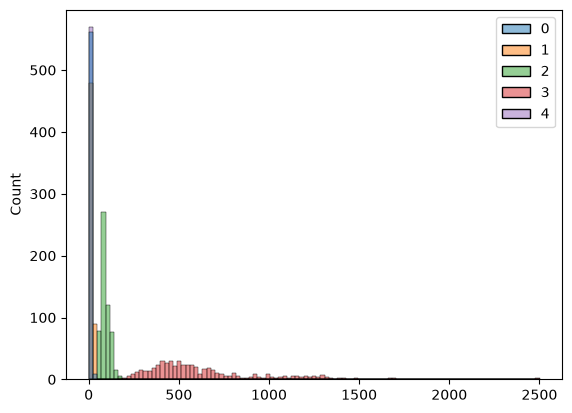

In [3]:
for i, name in enumerate(data.feature_names[:10]):
    print(
        f"{name:25s} "
        f"min={X[:, i].min():10.4f} "
        f"max={X[:, i].max():10.4f}"
    )
    
sns.histplot(data=X[:, :5])

## Split the dataset into training and testing sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(398, 30)
(171, 30)
(398,)
(171,)


## Fit classification model

In [5]:
# Create a Perceptron model
clf = Perceptron(max_iter=1000, eta0=0.1)
# Train the model
clf.fit(X_train, y_train)

,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [6]:
# Make predictions
y_pred = clf.predict(X_test)
print(y_pred)

[0 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 1
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 0 0
 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1]


## Model accuracy

In [7]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy}")

Accuracy:0.935672514619883


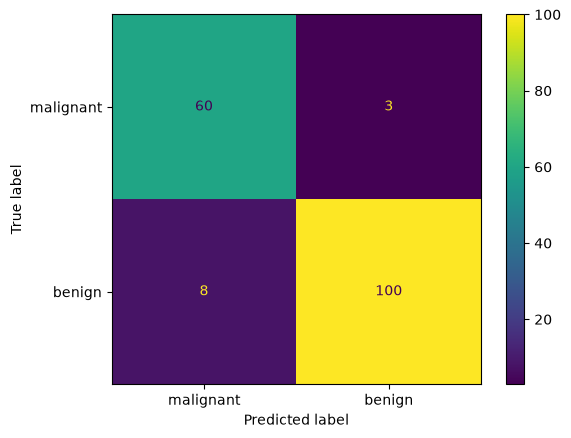

In [8]:
# Calculate confusion matrix
from matplotlib import pyplot as plt
conf_matrix = confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = data.target_names)

cm_display.plot()
plt.show()

## <font color='orange'>Exercise </font>

The data was not scaled in ths above example try to retrain using scaling and creating a pipeline as discussed in the previous demos.

# Multiclass Classification using Perceptron

## Load data samples and plot

In [9]:
from sklearn.datasets import fetch_openml


In [16]:
# Load the MNIST dataset
from sklearn.datasets import load_digits

mnist = fetch_openml('mnist_784')
X = mnist.data
y = mnist.target.astype(int)
print(X.shape)
print(y.shape)
print(y[:10])

(70000, 784)
(70000,)
0    5
1    0
2    4
3    1
4    9
5    2
6    1
7    3
8    1
9    4
Name: class, dtype: int64


## Visualizing the vectorized image data

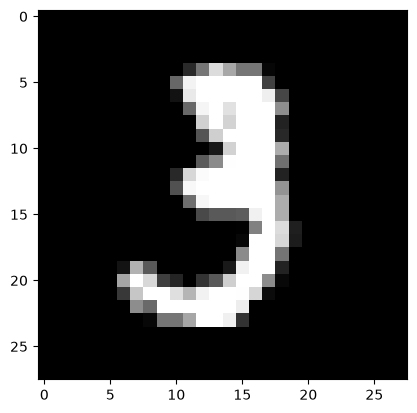

In [11]:
X_img = X.to_numpy().reshape((70000,28,28))/255.0
plt.imshow(X_img[10,:,:], interpolation='nearest', cmap='gray')
plt.show()


## Split the dataset into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

## Create a Perceptron classifier model

In [21]:
perceptron = Perceptron(max_iter=1000, eta0=0.1)
# Train the model
perceptron.fit(X_train, y_train)

,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [22]:
# Make predictions
y_pred = perceptron.predict(X_test)
print(y_pred)
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


[7 8 2 ... 8 6 4]
Accuracy: 0.8685714285714285


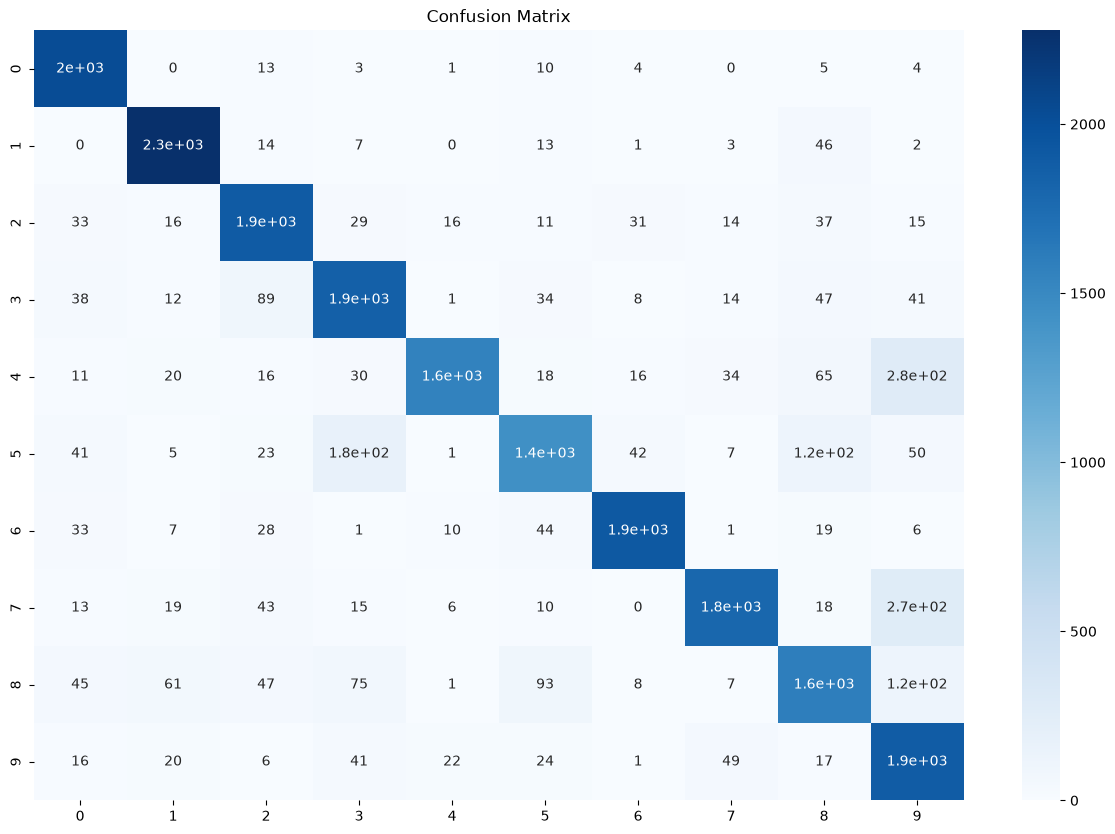

In [23]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15, 10), sharey=True)
sns.heatmap(conf_matrix, annot = True, cmap= 'Blues')
plt.title('Confusion Matrix')
plt.show()

## <font color='orange'>Exercise </font>

Try using stratification in the train-test split. See its effect of classification accuracy. 

<font color='green'>Note: </font>: Scaling is not required here as the data is already in the reange of 0-1.